# Batch Inference FirstPass + Tracking per Cyclone

Notebook per:
- lanciare `scripts/predict_firstpass_and_track_from_folder.py` su tutte le cartelle `fromgcloud/<id_ciclone>`;
- usare la soglia per-ciclone dalla **ultima cella** di `moduli/firstpass/notebooks/per_cyclone_threshold_analysis.ipynb`;
- analizzare la distribuzione degli errori di tracking (km);
- visualizzare la traccia GT vs predetta su mappa Mediterraneo.

La cella di esecuzione subprocess usa solo variabili definite nel notebook.


In [10]:
from __future__ import annotations

import ast
import json
import shlex
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')


In [11]:
# Risoluzione root repo in modo robusto

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / 'scripts' / 'predict_firstpass_and_track_from_folder.py').exists():
            return p
    raise FileNotFoundError('Repository root non trovato a partire da cwd.')

REPO_ROOT = find_repo_root(Path.cwd())
SCRIPT_PATH = REPO_ROOT / 'scripts' / 'predict_firstpass_and_track_from_folder.py'
THRESH_NOTEBOOK = REPO_ROOT / 'moduli' / 'firstpass' / 'notebooks' / 'per_cyclone_threshold_analysis.ipynb'

print('REPO_ROOT:', REPO_ROOT)
print('SCRIPT_PATH:', SCRIPT_PATH)
print('THRESH_NOTEBOOK:', THRESH_NOTEBOOK)


REPO_ROOT: /media/isacDisk1/Demetra
SCRIPT_PATH: /media/isacDisk1/Demetra/scripts/predict_firstpass_and_track_from_folder.py
THRESH_NOTEBOOK: /media/isacDisk1/Demetra/moduli/firstpass/notebooks/per_cyclone_threshold_analysis.ipynb


In [12]:
# Caricamento soglie dalla ULTIMA cella code non vuota del notebook per-cyclone

def normalize_cyclone_id(v) -> str:
    if pd.isna(v):
        return ''
    s = str(v).strip()
    if not s:
        return ''
    try:
        f = float(s)
        if f.is_integer():
            return str(int(f))
    except Exception:
        pass
    return s


def extract_thresholds_from_last_cell(nb_path: Path) -> dict[str, float]:
    nb = json.loads(nb_path.read_text())
    code_cells = [
        ''.join(c.get('source', []))
        for c in nb.get('cells', [])
        if c.get('cell_type') == 'code' and ''.join(c.get('source', [])).strip()
    ]
    if not code_cells:
        raise RuntimeError(f'Nessuna cella code non vuota in {nb_path}')

    last_src = code_cells[-1]
    tree = ast.parse(last_src)

    dict_obj = None
    for node in tree.body:
        if isinstance(node, ast.Assign) and isinstance(node.value, ast.Dict):
            try:
                candidate = ast.literal_eval(node.value)
            except Exception:
                continue
            if isinstance(candidate, dict) and candidate:
                dict_obj = candidate

    if not isinstance(dict_obj, dict) or not dict_obj:
        raise RuntimeError(
            'Ultima cella code non contiene un dizionario soglie assegnato. '
            'Controlla per_cyclone_threshold_analysis.ipynb'
        )

    out: dict[str, float] = {}
    for k, v in dict_obj.items():
        kid = normalize_cyclone_id(k)
        if not kid:
            continue
        try:
            out[kid] = float(v)
        except Exception:
            continue

    if not out:
        raise RuntimeError('Dizionario soglie estratto ma vuoto/non valido.')
    return out


THRESHOLDS_BY_ID = extract_thresholds_from_last_cell(THRESH_NOTEBOOK)
print('Soglie caricate:', len(THRESHOLDS_BY_ID))
print('Esempio:', list(THRESHOLDS_BY_ID.items()))


Soglie caricate: 18
Esempio: [('7001702', 0.3), ('7001283', 0.335), ('7001328', 0.515), ('7001358', 0.255), ('7001421', 0.465), ('7001461', 0.19), ('7001466', 0.335), ('7001500', 0.435), ('7001521', 0.395), ('7001542', 0.56), ('7001575', 0.635), ('7001674', 0.43), ('7001715', 0.06), ('7001716', 0.065), ('39299', 0.09), ('82258', 0.125), ('46218', 0.245), ('83565', 0.21)]


In [13]:
# Configurazione batch run (modifica qui)

PYTHON_BIN = sys.executable
FROMGCLOUD_DIR = Path('/media/isacDisk1/fromgcloud')
#OUTPUT_ROOT = Path('/media/isacDisk1/airmassRGB')
OUTPUT_ROOT = Path('/media/isacDisk2/demetra_output/')

FIRSTPASS_MODEL_PATH = REPO_ROOT / 'trained_models' / 'firstpass_model.ckpt'
TRACKING_MODEL_PATH = REPO_ROOT / 'trained_models' / 'checkpoint-tracking-best_1.pth'
MANOS_FILE = REPO_ROOT / 'moduli' / 'videomae' / 'medicane_data_input' / 'medicanes_new_windows.csv'

FIRSTPASS_BATCH_SIZE = 64
FIRSTPASS_NUM_WORKERS = 10


# Se vuoi filtrare un sottoinsieme: ['7001421', '83565']
SELECT_ONLY_IDS = None

# Fallback se un id non ha soglia specifica nel dizionario
DEFAULT_THRESHOLD = 0.50

# Sicurezza: metti True per eseguire davvero
RUN_ENABLED = True

FFMPEG_PATH = '/media/isacDisk1/VideoMAEv2/ffmpeg-7.0.2-amd64-static/'

print('OUTPUT_ROOT:', OUTPUT_ROOT)


OUTPUT_ROOT: /media/isacDisk2/demetra_output


In [14]:
# Scansione cartelle input e piano esecuzione

if not FROMGCLOUD_DIR.exists():
    raise FileNotFoundError(f'Input root non trovata: {FROMGCLOUD_DIR}')

all_dirs = sorted([p for p in FROMGCLOUD_DIR.iterdir() if p.is_dir()])
plan_rows = []
for d in all_dirs:
    cid = normalize_cyclone_id(d.name)
    if not cid:
        continue
    if SELECT_ONLY_IDS is not None and cid not in {normalize_cyclone_id(x) for x in SELECT_ONLY_IDS}:
        continue
    thr = float(THRESHOLDS_BY_ID.get(cid, DEFAULT_THRESHOLD))
    out_dir = OUTPUT_ROOT / cid
    plan_rows.append({
        'cyclone_id': cid,
        'input_dir': str(d),
        'output_dir': str(out_dir),
        'firstpass_threshold': thr,
        'threshold_source': 'per_cyclone' if cid in THRESHOLDS_BY_ID else 'default',
    })

plan_df = pd.DataFrame(plan_rows).sort_values('cyclone_id').reset_index(drop=True)
print(f'Cyclone folders in piano: {len(plan_df)}')
plan_df.head(20)


Cyclone folders in piano: 20


,cyclone_id,input_dir,output_dir,firstpass_threshold,threshold_source
0,2020,/media/isacDisk1/fromgcloud/2020,/media/isacDisk2/demetra_output/2020,0.500,default
1,2023,/media/isacDisk1/fromgcloud/2023,/media/isacDisk2/demetra_output/2023,0.500,default
2,39299,/media/isacDisk1/fromgcloud/39299,/media/isacDisk2/demetra_output/39299,0.090,per_cyclone
3,46218,/media/isacDisk1/fromgcloud/46218,/media/isacDisk2/demetra_output/46218,0.245,per_cyclone
4,7001283,/media/isacDisk1/fromgcloud/7001283,/media/isacDisk2/demetra_output/7001283,0.335,per_cyclone
5,7001328,/media/isacDisk1/fromgcloud/7001328,/media/isacDisk2/demetra_output/7001328,0.515,per_cyclone
6,7001358,/media/isacDisk1/fromgcloud/7001358,/media/isacDisk2/demetra_output/7001358,0.255,per_cyclone
7,7001421,/media/isacDisk1/fromgcloud/7001421,/media/isacDisk2/demetra_output/7001421,0.465,per_cyclone
8,7001461,/media/isacDisk1/fromgcloud/7001461,/media/isacDisk2/demetra_output/7001461,0.190,per_cyclone
9,7001466,/media/isacDisk1/fromgcloud/7001466,/media/isacDisk2/demetra_output/7001466,0.335,per_cyclone


In [15]:
plan_df.loc[plan_df.cyclone_id == '2020', 'firstpass_threshold'] = round(np.mean(list(THRESHOLDS_BY_ID.values())), 3)

In [16]:
plan_df = plan_df[0:1]
plan_df

,cyclone_id,input_dir,output_dir,firstpass_threshold,threshold_source
0,2020,/media/isacDisk1/fromgcloud/2020,/media/isacDisk2/demetra_output/2020,0.314,default


In [ ]:
# Esecuzione batch via subprocess

def build_cmd(row: pd.Series) -> list[str]:
    cmd = [
        str(PYTHON_BIN),
        str(SCRIPT_PATH),
        '--input_dir', str(row['input_dir']),
        '--output_dir', str(row['output_dir']),
        '--firstpass_model_path', str(FIRSTPASS_MODEL_PATH),
        '--tracking_model_path', str(TRACKING_MODEL_PATH),
        '--firstpass_threshold', f"{float(row['firstpass_threshold']):.3f}",
        '--manos_file', str(MANOS_FILE),
        '--firstpass_batch_size', str(int(FIRSTPASS_BATCH_SIZE)),
        '--firstpass_num_workers', str(int(FIRSTPASS_NUM_WORKERS)),
        '--standard_tiling',
        '--make_video',
        '--ffmpeg_path', str(FFMPEG_PATH),
    ]
    return cmd

run_rows = []
if not RUN_ENABLED:
    print('RUN_ENABLED=False: nessun subprocess lanciato. Metti RUN_ENABLED=True e rilancia questa cella.')
else:
    for _, row in plan_df.iterrows():
        cmd = build_cmd(row)
        print('\n' + '=' * 100)
        print(f"Cyclone {row['cyclone_id']} | threshold={row['firstpass_threshold']:.3f} ({row['threshold_source']})")
        print(shlex.join(cmd))

        t0 = time.time()
        proc = subprocess.run(cmd, cwd=str(REPO_ROOT), text=True)
        dt = time.time() - t0

        run_rows.append({
            'cyclone_id': row['cyclone_id'],
            'return_code': int(proc.returncode),
            'elapsed_sec': round(dt, 2),
            'output_dir': row['output_dir'],
            'threshold': float(row['firstpass_threshold']),
        })

run_df = pd.DataFrame(run_rows)
if not run_df.empty:
    display(run_df)
    print('Fail count:', int((run_df['return_code'] != 0).sum()))
else:
    print('Nessun run eseguito.')
    


In [9]:
# Raccolta CSV tracking tile-level dai run (utile per metriche err_px / err_km)

if 'run_df' in globals() and not run_df.empty:
    source_df = run_df.copy()
else:
    source_df = plan_df.copy()

rows = []
for _, r in source_df.iterrows():
    cid = normalize_cyclone_id(r['cyclone_id'])
    out_dir = Path(r['output_dir'])
    csv_path = out_dir / '_tmp_tracking_inference_predictions_tiles.csv'
    if not csv_path.exists():
        continue
    try:
        df = pd.read_csv(csv_path)
    except Exception as exc:
        print(f'[WARN] Impossibile leggere {csv_path}: {exc}')
        continue
    df['cyclone_id'] = cid
    df['output_dir'] = str(out_dir)
    rows.append(df)

if rows:
    all_tile_preds = pd.concat(rows, ignore_index=True)
else:
    all_tile_preds = pd.DataFrame()

print('Rows tile predictions:', len(all_tile_preds))
if not all_tile_preds.empty:
    if 'has_target' in all_tile_preds.columns:
        print('has_target counts:', all_tile_preds['has_target'].value_counts(dropna=False).to_dict())
    display(all_tile_preds.head(10))


Rows tile predictions: 3693
has_target counts: {0: 3602, 1: 91}


,path,has_target,pred_x,pred_y,target_x,target_y,err_px,err_km,tile_offset_x,tile_offset_y,pred_x_global,pred_y_global,pred_lat,pred_lon,target_x_global,target_y_global,target_lat,target_lon,cyclone_id,output_dir
0,06-01-2020_0030_852_196,0,95,103,NaN,NaN,NaN,NaN,852.0,196.0,947,299,34.19,24.51,NaN,NaN,NaN,NaN,2020,/media/isacDisk1/airmassRGB/2020
1,06-01-2020_0115_852_196,0,85,91,NaN,NaN,NaN,NaN,852.0,196.0,937,287,34.62,24.24,NaN,NaN,NaN,NaN,2020,/media/isacDisk1/airmassRGB/2020
2,06-01-2020_0130_852_196,0,96,92,NaN,NaN,NaN,NaN,852.0,196.0,948,288,34.60,24.63,NaN,NaN,NaN,NaN,2020,/media/isacDisk1/airmassRGB/2020
3,06-01-2020_0600_852_196,0,74,58,NaN,NaN,NaN,NaN,852.0,196.0,926,254,35.85,24.11,NaN,NaN,NaN,NaN,2020,/media/isacDisk1/airmassRGB/2020
4,06-01-2020_0615_852_196,0,80,64,NaN,NaN,NaN,NaN,852.0,196.0,932,260,35.63,24.28,NaN,NaN,NaN,NaN,2020,/media/isacDisk1/airmassRGB/2020
5,06-01-2020_0630_852_196,0,78,56,NaN,NaN,NaN,NaN,852.0,196.0,930,252,35.93,24.27,NaN,NaN,NaN,NaN,2020,/media/isacDisk1/airmassRGB/2020
6,06-01-2020_0645_852_196,0,80,58,NaN,NaN,NaN,NaN,852.0,196.0,932,254,35.86,24.33,NaN,NaN,NaN,NaN,2020,/media/isacDisk1/airmassRGB/2020
7,06-01-2020_0700_852_196,0,45,62,NaN,NaN,NaN,NaN,852.0,196.0,897,258,35.67,23.03,NaN,NaN,NaN,NaN,2020,/media/isacDisk1/airmassRGB/2020
8,06-01-2020_0715_852_196,0,35,53,NaN,NaN,NaN,NaN,852.0,196.0,887,249,36.00,22.74,NaN,NaN,NaN,NaN,2020,/media/isacDisk1/airmassRGB/2020
9,06-01-2020_0730_852_196,0,70,65,NaN,NaN,NaN,NaN,852.0,196.0,922,261,35.58,23.91,NaN,NaN,NaN,NaN,2020,/media/isacDisk1/airmassRGB/2020


Rows with GT (has_target=1, hourly-only): 91
N err_km > 0: 89
Median err_km: 14.34478353437472
Mean err_km: 31.49225853750347


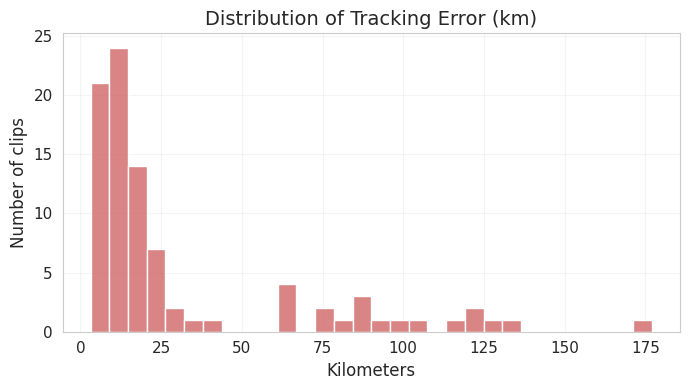

In [10]:
# ### Distribuzione degli errori (solo GT oraria, no interpolazione temporale)

fig, ax = plt.subplots(figsize=(7, 4), tight_layout=True)

if not all_tile_preds.empty and 'err_km' in all_tile_preds.columns and all_tile_preds['err_km'].notna().any():
    err_df = all_tile_preds.copy()

    # Usa solo righe con GT reale disponibile.
    if 'has_target' in err_df.columns:
        err_df = err_df[pd.to_numeric(err_df['has_target'], errors='coerce') == 1]

    # Safety check: considera solo tile con timestamp all'ora intera (HH:00).
    if 'path' in err_df.columns:
        path_base = err_df['path'].astype(str).str.replace(r'.*[\/]', '', regex=True)
        dt_str = path_base.str.extract(r'^(\d{2}-\d{2}-\d{4}_\d{4})', expand=False)
        tile_dt = pd.to_datetime(dt_str, format='%d-%m-%Y_%H%M', errors='coerce')
        err_df = err_df[tile_dt.notna() & (tile_dt.dt.minute == 0)].copy()

    data = pd.to_numeric(err_df['err_km'], errors='coerce').dropna()
    positive_data = data[data > 0]

    print('Rows with GT (has_target=1, hourly-only):', len(data))

    if not positive_data.empty:
        #bins = np.logspace(np.log10(positive_data.min()), np.log10(positive_data.max()), 30)
        sns.histplot(positive_data, bins=30, ax=ax, color='indianred')
        #ax.set_xscale('log')
        ax.set_title('Distribution of Tracking Error (km)', fontsize=14)
        ax.set_xlabel('Kilometers', fontsize=12)
        ax.set_ylabel('Number of clips', fontsize=12)
        ax.tick_params(axis='both', labelsize=11)
        ax.grid(alpha=0.2)
        print('N err_km > 0:', len(positive_data))
        print('Median err_km:', float(np.median(positive_data)))
        print('Mean err_km:', float(np.mean(positive_data)))
    else:
        ax.text(0.5, 0.5, 'All err_km values are <= 0', ha='center', va='center', fontsize=12)
        ax.set_axis_off()
else:
    ax.text(0.5, 0.5, 'err_km column not available', ha='center', va='center', fontsize=12)
    ax.set_axis_off()

plt.savefig('tracking_error_distribution_2020.png', dpi=150)
plt.show()


In [17]:
# Configurazione plot traccia su mappa Mediterraneo

MAP_CYCLONE_ID = None  # es: '7001421'. Se None usa il primo id disponibile nel piano.

if MAP_CYCLONE_ID is None:
    if len(plan_df) == 0:
        raise RuntimeError('plan_df vuoto: nessun ciclone disponibile.')
    MAP_CYCLONE_ID = str(plan_df.iloc[0]['cyclone_id'])

MAP_CYCLONE_ID = normalize_cyclone_id(MAP_CYCLONE_ID)
PRED_CSV = OUTPUT_ROOT / MAP_CYCLONE_ID / 'tracking_inference_predictions.csv'

print('MAP_CYCLONE_ID:', MAP_CYCLONE_ID)
print('PRED_CSV:', PRED_CSV)


MAP_CYCLONE_ID: 2020
PRED_CSV: /media/isacDisk2/demetra_output/2020/tracking_inference_predictions.csv


Pred rows (VideoMAE has_cyclone=1): 3693 | GT rows: 0


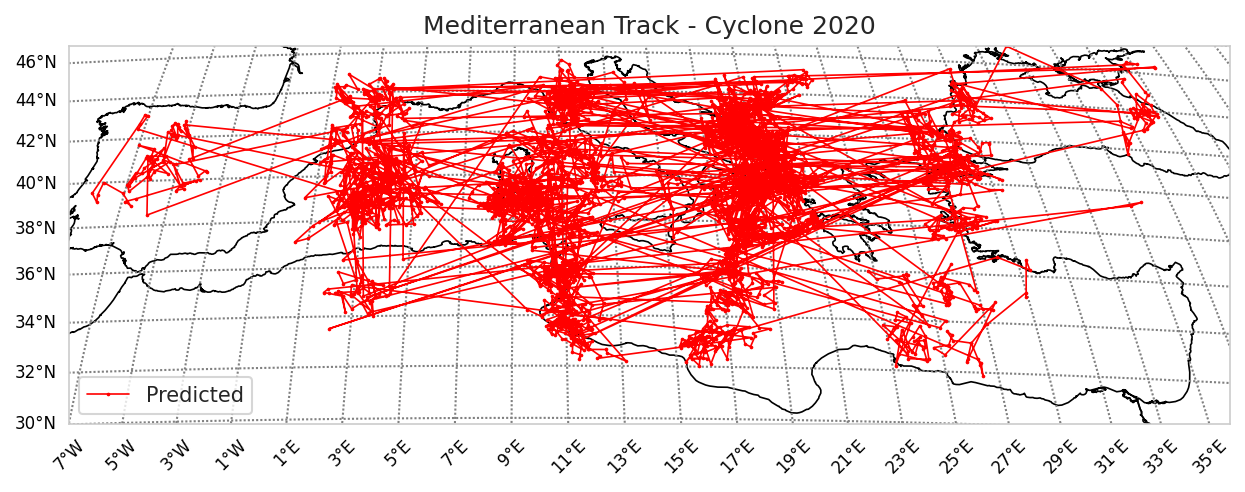

In [12]:
# Traccia GT (verde) vs predetta (rosso) su basemap Mediterraneo

# Import basemap helper come in plot_med_domain_bw_basemap.py
VIDEOMAE_DIR = REPO_ROOT / 'moduli' / 'videomae'
if str(VIDEOMAE_DIR) not in sys.path:
    sys.path.insert(0, str(VIDEOMAE_DIR))

from medicane_utils.geo_const import latcorners, loncorners, create_basemap_obj

if not PRED_CSV.exists():
    raise FileNotFoundError(f'CSV predizioni non trovato: {PRED_CSV}')

pred_df = pd.read_csv(PRED_CSV)
pred_df['datetime'] = pd.to_datetime(pred_df.get('datetime'), errors='coerce')
pred_df['pred_lat'] = pd.to_numeric(pred_df.get('pred_lat'), errors='coerce')
pred_df['pred_lon'] = pd.to_numeric(pred_df.get('pred_lon'), errors='coerce')

if 'has_cyclone' in pred_df.columns:
    pred_df['has_cyclone'] = pd.to_numeric(pred_df['has_cyclone'], errors='coerce').fillna(0).astype(int)
else:
    pred_df['has_cyclone'] = 1

# Usa solo la traccia VideoMAE (has_cyclone=1), escludendo la coarse first-pass.
pred_df = pred_df[
    (pred_df['has_cyclone'] == 1)
    & pred_df['datetime'].notna()
    & pred_df['pred_lat'].notna()
    & pred_df['pred_lon'].notna()
].copy().sort_values('datetime')

if pred_df.empty:
    raise RuntimeError('Nessuna predizione VideoMAE (has_cyclone=1) disponibile per il ciclone selezionato.')

# GT da manos_file
manos_df = pd.read_csv(MANOS_FILE)
if 'id_cyc_unico' not in manos_df.columns:
    raise RuntimeError(f'manos_file senza colonna id_cyc_unico: {MANOS_FILE}')

manos_df['cyclone_id'] = manos_df['id_cyc_unico'].apply(normalize_cyclone_id)
manos_df['time'] = pd.to_datetime(manos_df.get('time'), errors='coerce')
manos_df['lat'] = pd.to_numeric(manos_df.get('lat'), errors='coerce')
manos_df['lon'] = pd.to_numeric(manos_df.get('lon'), errors='coerce')

gt_df = manos_df[
    (manos_df['cyclone_id'] == MAP_CYCLONE_ID)
    & manos_df['time'].notna()
    & manos_df['lat'].notna()
    & manos_df['lon'].notna()
].copy().sort_values('time')

print('Pred rows (VideoMAE has_cyclone=1):', len(pred_df), '| GT rows:', len(gt_df))

fig = plt.figure(figsize=(9, 6), dpi=150)
ax = fig.add_axes([0.07, 0.08, 0.86, 0.84])
m = create_basemap_obj(ax=ax)

m.drawcoastlines(linewidth=0.8, color='black', zorder=2)

lat_min, lat_max = latcorners
lon_min, lon_max = loncorners
parallels = np.arange(lat_min, lat_max + 0.1, 2.0)
meridians = np.arange(lon_min, lon_max + 0.1, 2.0)
m.drawparallels(parallels, labels=[1, 0, 0, 0], fontsize=8, color='0.5')
m.drawmeridians(meridians, labels=[0, 0, 0, 1], fontsize=8, color='0.5', rotation=45)

# Traccia predetta
x_pred, y_pred = m(pred_df['pred_lon'].to_numpy(), pred_df['pred_lat'].to_numpy())
m.plot(x_pred, y_pred, color='red', linewidth=0.8, marker='.', markersize=1.5, label='Predicted')

# Traccia GT
if not gt_df.empty:
    x_gt, y_gt = m(gt_df['lon'].to_numpy(), gt_df['lat'].to_numpy())
    m.plot(x_gt, y_gt, color='green', linewidth=0.8, marker='.', markersize=1.5, label='Ground Truth')

ax.set_title(f'Mediterranean Track - Cyclone {MAP_CYCLONE_ID}')
ax.legend(loc='lower left')
plt.savefig(f'mediterranean_track_{MAP_CYCLONE_ID}.png', dpi=150)
plt.show()


# CL7 validation

Impossibile caricare la libreria torch dynamo
CL7_PRED_CSV: /media/isacDisk1/Demetra/notebooks/tracking_inference_predictions.csv
CL7_LABELS_CSV: /media/isacDisk1/Demetra/notebooks/manos_CL7_pixel.csv
MERCAD_LABELS_CSV: /media/isacDisk1/Demetra/notebooks/mercad_tracks_merged.csv
Saved: /media/isacDisk1/Demetra/notebooks/cl7_validation_outputs/tracking_inference_predictions_cl7_mercad_validation.csv | rows: 6305
Pred has_cyclone      0    1
True CL7 presence           
0                  4299  574
1                  1167  265
Accuracy=0.7239 Precision=0.3159 Recall=0.1851 F1=0.2334


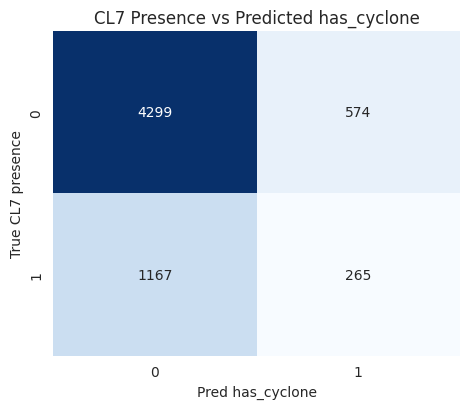

Saved: /media/isacDisk1/Demetra/notebooks/cl7_validation_outputs/cl7_confusion_matrix.png


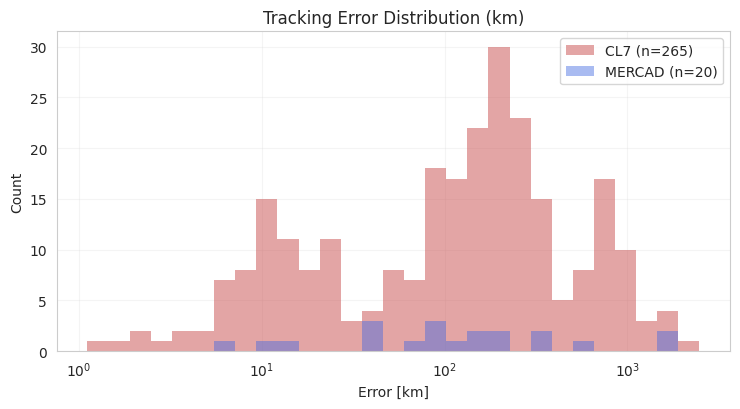

Saved: /media/isacDisk1/Demetra/notebooks/cl7_validation_outputs/cl7_mercad_error_hist_km.png


In [18]:
# CL7 validation (dry-run, no video)
# Riusa variabili/import globali del notebook: REPO_ROOT, np, pd, plt, sns, normalize_cyclone_id

VIDEOMAE_DIR = REPO_ROOT / 'moduli' / 'videomae'
if str(VIDEOMAE_DIR) not in sys.path:
    sys.path.insert(0, str(VIDEOMAE_DIR))

from track_from_folder import _parse_datetime_series
import engine_for_tracking as tracking_engine

NOTEBOOKS_DIR = REPO_ROOT / 'notebooks'
CL7_PRED_CSV = NOTEBOOKS_DIR / 'tracking_inference_predictions.csv'
CL7_LABELS_CSV = NOTEBOOKS_DIR / 'manos_CL7_pixel.csv'
MERCAD_LABELS_CSV = NOTEBOOKS_DIR / 'mercad_tracks_merged.csv'

CL7_OUT_DIR = NOTEBOOKS_DIR / 'cl7_validation_outputs'
CL7_OUT_DIR.mkdir(parents=True, exist_ok=True)
CL7_JOIN_CSV = CL7_OUT_DIR / 'tracking_inference_predictions_cl7_mercad_validation.csv'
CL7_CM_PNG = CL7_OUT_DIR / 'cl7_confusion_matrix.png'
CL7_HIST_PNG = CL7_OUT_DIR / 'cl7_mercad_error_hist_km.png'

for fp in [CL7_PRED_CSV, CL7_LABELS_CSV, MERCAD_LABELS_CSV]:
    if not fp.exists():
        raise FileNotFoundError(f'File non trovato: {fp}')

print('CL7_PRED_CSV:', CL7_PRED_CSV)
print('CL7_LABELS_CSV:', CL7_LABELS_CSV)
print('MERCAD_LABELS_CSV:', MERCAD_LABELS_CSV)

pred_df = pd.read_csv(CL7_PRED_CSV)
pred_df['datetime'] = _parse_datetime_series(pred_df.get('datetime'))
pred_df['has_cyclone'] = pd.to_numeric(pred_df.get('has_cyclone'), errors='coerce').fillna(0).astype(int)
pred_df['pred_lat'] = pd.to_numeric(pred_df.get('pred_lat'), errors='coerce')
pred_df['pred_lon'] = pd.to_numeric(pred_df.get('pred_lon'), errors='coerce')
pred_df = pred_df[pred_df['datetime'].notna()].copy().sort_values('datetime')

# GT CL7 disponibile ad ora intera: validazione hourly-only.
pred_df = pred_df[
    (pred_df['datetime'].dt.minute == 0)
    & (pred_df['datetime'].dt.second == 0)
    & (pred_df['datetime'].dt.microsecond == 0)
].copy()

cl7_df = pd.read_csv(CL7_LABELS_CSV)
cl7_df['time'] = _parse_datetime_series(cl7_df.get('time'))
cl7_df['lat'] = pd.to_numeric(cl7_df.get('lat'), errors='coerce')
cl7_df['lon'] = pd.to_numeric(cl7_df.get('lon'), errors='coerce')
cl7_df['cyclone_id'] = cl7_df.get('id_cyc_unico').apply(normalize_cyclone_id)
cl7_df = cl7_df[
    cl7_df['time'].notna() & cl7_df['lat'].notna() & cl7_df['lon'].notna() & (cl7_df['cyclone_id'] != '')
].copy().sort_values('time')

mercad_df = pd.read_csv(MERCAD_LABELS_CSV)
mercad_df['time'] = _parse_datetime_series(mercad_df.get('time'))
mercad_df['mercad_lat'] = pd.to_numeric(mercad_df.get('mercad_lat'), errors='coerce')
mercad_df['mercad_lon'] = pd.to_numeric(mercad_df.get('mercad_lon'), errors='coerce')
mercad_df = mercad_df[
    mercad_df['time'].notna() & mercad_df['mercad_lat'].notna() & mercad_df['mercad_lon'].notna()
].copy().sort_values('time')
mercad_df['time_hour'] = mercad_df['time'].dt.round('h')

if pred_df.empty:
    raise RuntimeError('Predizioni hourly vuote.')
if cl7_df.empty:
    raise RuntimeError('CL7 vuoto/non valido.')

overlap_start = max(pred_df['datetime'].min(), cl7_df['time'].min())
overlap_end = min(pred_df['datetime'].max(), cl7_df['time'].max())
if overlap_end < overlap_start:
    raise RuntimeError('Nessuna sovrapposizione temporale tra predictions e CL7.')

pred_eval = pred_df[(pred_df['datetime'] >= overlap_start) & (pred_df['datetime'] <= overlap_end)].copy().sort_values('datetime')
cl7_eval = cl7_df[(cl7_df['time'] >= overlap_start) & (cl7_df['time'] <= overlap_end)].copy()
mercad_eval = mercad_df[(mercad_df['time_hour'] >= overlap_start) & (mercad_df['time_hour'] <= overlap_end)].copy()

# Classification target: presenza CL7 al timestamp.
cl7_presence = cl7_eval.groupby('time').size().rename('cl7_n_points')
pred_eval = pred_eval.merge(cl7_presence, left_on='datetime', right_index=True, how='left')
pred_eval['cl7_n_points'] = pred_eval['cl7_n_points'].fillna(0).astype(int)
pred_eval['y_true_cl7_presence'] = (pred_eval['cl7_n_points'] > 0).astype(int)
pred_eval['y_pred_has_cyclone'] = pred_eval['has_cyclone'].astype(int)

cl7_by_time = {t: g for t, g in cl7_eval.groupby('time')}
mercad_by_time = {t: g for t, g in mercad_eval.groupby('time_hour')}

rows = []
for r in pred_eval.itertuples(index=False):
    dt = pd.Timestamp(r.datetime)
    pred_lat = pd.to_numeric(r.pred_lat, errors='coerce')
    pred_lon = pd.to_numeric(r.pred_lon, errors='coerce')
    has_cyc = int(r.has_cyclone)

    out = {
        'datetime': dt,
        'has_cyclone': has_cyc,
        'pred_lat': pred_lat,
        'pred_lon': pred_lon,
        'y_true_cl7_presence': int(r.y_true_cl7_presence),
        'y_pred_has_cyclone': int(r.y_pred_has_cyclone),
        'cl7_n_points': int(r.cl7_n_points),
        'cl7_match_id': '',
        'cl7_match_lat': np.nan,
        'cl7_match_lon': np.nan,
        'err_km_cl7': np.nan,
        'mercad_n_points': 0,
        'mercad_match_idorig': np.nan,
        'mercad_match_lat': np.nan,
        'mercad_match_lon': np.nan,
        'err_km_mercad': np.nan,
    }

    if has_cyc == 1 and np.isfinite(pred_lat) and np.isfinite(pred_lon):
        g = cl7_by_time.get(dt)
        if g is not None and not g.empty:
            d = tracking_engine._haversine_km(
                np.full(len(g), float(pred_lat)),
                np.full(len(g), float(pred_lon)),
                g['lat'].to_numpy(dtype=float),
                g['lon'].to_numpy(dtype=float),
            )
            i = int(np.argmin(d))
            row_i = g.iloc[i]
            out['cl7_match_id'] = normalize_cyclone_id(row_i.get('id_cyc_unico'))
            out['cl7_match_lat'] = float(row_i['lat'])
            out['cl7_match_lon'] = float(row_i['lon'])
            out['err_km_cl7'] = float(d[i])

        gm = mercad_by_time.get(dt)
        if gm is not None and not gm.empty:
            out['mercad_n_points'] = int(len(gm))
            d2 = tracking_engine._haversine_km(
                np.full(len(gm), float(pred_lat)),
                np.full(len(gm), float(pred_lon)),
                gm['mercad_lat'].to_numpy(dtype=float),
                gm['mercad_lon'].to_numpy(dtype=float),
            )
            j = int(np.argmin(d2))
            row_j = gm.iloc[j]
            out['mercad_match_idorig'] = row_j.get('idorig')
            out['mercad_match_lat'] = float(row_j['mercad_lat'])
            out['mercad_match_lon'] = float(row_j['mercad_lon'])
            out['err_km_mercad'] = float(d2[j])

    rows.append(out)

cl7_val_df = pd.DataFrame(rows).sort_values('datetime').reset_index(drop=True)
cl7_val_df.to_csv(CL7_JOIN_CSV, index=False)
print('Saved:', CL7_JOIN_CSV, '| rows:', len(cl7_val_df))

# --- confusion matrix ---
cm = pd.crosstab(
    cl7_val_df['y_true_cl7_presence'],
    cl7_val_df['y_pred_has_cyclone'],
    rownames=['True CL7 presence'],
    colnames=['Pred has_cyclone'],
    dropna=False,
).reindex(index=[0, 1], columns=[0, 1], fill_value=0)

TN = int(cm.loc[0, 0]); FP = int(cm.loc[0, 1]); FN = int(cm.loc[1, 0]); TP = int(cm.loc[1, 1])
acc = (TP + TN) / max(1, (TP + TN + FP + FN))
prec = TP / max(1, (TP + FP))
rec = TP / max(1, (TP + FN))
f1 = 2 * prec * rec / max(1e-12, (prec + rec))

print(cm)
print(f'Accuracy={acc:.4f} Precision={prec:.4f} Recall={rec:.4f} F1={f1:.4f}')

fig, ax = plt.subplots(figsize=(4.8, 4.2), tight_layout=True)
sns.heatmap(cm, annot=True, fmt='d', cbar=False, cmap='Blues', ax=ax)
ax.set_title('CL7 Presence vs Predicted has_cyclone')
fig.savefig(CL7_CM_PNG, dpi=150)
plt.show()
print('Saved:', CL7_CM_PNG)

# --- error histogram ---
cl7_err = pd.to_numeric(cl7_val_df['err_km_cl7'], errors='coerce').dropna()
cl7_err = cl7_err[cl7_err > 0]
mercad_err = pd.to_numeric(cl7_val_df['err_km_mercad'], errors='coerce').dropna()
mercad_err = mercad_err[mercad_err > 0]

fig, ax = plt.subplots(figsize=(7.5, 4.2), tight_layout=True)
if not cl7_err.empty or not mercad_err.empty:
    vals = []
    if not cl7_err.empty:
        vals.extend(cl7_err.tolist())
    if not mercad_err.empty:
        vals.extend(mercad_err.tolist())
    bins = np.logspace(np.log10(max(1e-3, float(np.min(vals)))), np.log10(float(np.max(vals))), 30)

    if not cl7_err.empty:
        sns.histplot(cl7_err, bins=bins, color='indianred', alpha=0.55, ax=ax, label=f'CL7 (n={len(cl7_err)})')
    if not mercad_err.empty:
        sns.histplot(mercad_err, bins=bins, color='royalblue', alpha=0.45, ax=ax, label=f'MERCAD (n={len(mercad_err)})')

    ax.set_xscale('log')
    ax.set_xlabel('Error [km]')
    ax.set_ylabel('Count')
    ax.set_title('Tracking Error Distribution (km)')
    ax.grid(alpha=0.2)
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No positive errors available', ha='center', va='center')
    ax.set_axis_off()

fig.savefig(CL7_HIST_PNG, dpi=150)
plt.show()
print('Saved:', CL7_HIST_PNG)


In [19]:
# CL7 static maps per-cyclone (periodo overlap con predictions)
# Crea una mappa PNG per ogni id_ciclone CL7 nel periodo, con:
# green=CL7 GT, red=predizioni matchate, blue=MERCAD matchato

if 'create_basemap_obj' not in globals():
    from medicane_utils.geo_const import latcorners, loncorners, create_basemap_obj

if 'cl7_val_df' not in globals():
    raise RuntimeError('Esegui prima la cella CL7 validation.')

maps_dir = CL7_OUT_DIR / 'maps_per_cyclone'
maps_dir.mkdir(parents=True, exist_ok=True)

cyclone_ids = sorted([cid for cid in cl7_eval['cyclone_id'].dropna().astype(str).unique() if cid])
print('Cyclones in overlap period:', len(cyclone_ids))

for cid in cyclone_ids:
    gt = cl7_eval[cl7_eval['cyclone_id'] == cid].copy().sort_values('time')
    pred_cid = cl7_val_df[
        (cl7_val_df['has_cyclone'] == 1)
        & (cl7_val_df['cl7_match_id'].astype(str) == str(cid))
        & cl7_val_df['pred_lat'].notna()
        & cl7_val_df['pred_lon'].notna()
    ].copy().sort_values('datetime')

    mercad_cid = cl7_val_df[
        (cl7_val_df['has_cyclone'] == 1)
        & (cl7_val_df['cl7_match_id'].astype(str) == str(cid))
        & cl7_val_df['mercad_match_lat'].notna()
        & cl7_val_df['mercad_match_lon'].notna()
    ].copy().sort_values('datetime')

    fig = plt.figure(figsize=(9, 6), dpi=140)
    ax = fig.add_axes([0.07, 0.08, 0.86, 0.84])
    m = create_basemap_obj(ax=ax)
    m.drawcoastlines(linewidth=0.8, color='black', zorder=2)

    lat_min, lat_max = latcorners
    lon_min, lon_max = loncorners
    parallels = np.arange(lat_min, lat_max + 0.1, 2.0)
    meridians = np.arange(lon_min, lon_max + 0.1, 2.0)
    m.drawparallels(parallels, labels=[1, 0, 0, 0], fontsize=8, color='0.5')
    m.drawmeridians(meridians, labels=[0, 0, 0, 1], fontsize=8, color='0.5', rotation=45)

    if not gt.empty:
        xg, yg = m(gt['lon'].to_numpy(), gt['lat'].to_numpy())
        m.plot(xg, yg, color='green', linewidth=1.2, marker='.', markersize=2, label='CL7 GT')

    if not pred_cid.empty:
        xr, yr = m(pred_cid['pred_lon'].to_numpy(), pred_cid['pred_lat'].to_numpy())
        m.plot(xr, yr, color='red', linewidth=1.2, marker='.', markersize=2, label='Prediction')

    if not mercad_cid.empty:
        xb, yb = m(mercad_cid['mercad_match_lon'].to_numpy(), mercad_cid['mercad_match_lat'].to_numpy())
        m.plot(xb, yb, color='royalblue', linewidth=1.2, marker='.', markersize=2, label='MERCAD')

    ax.set_title(f'CL7 Cyclone {cid} | GT vs Prediction vs MERCAD')
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        uniq = {}
        for h, l in zip(handles, labels):
            if l not in uniq:
                uniq[l] = h
        ax.legend(uniq.values(), uniq.keys(), loc='lower left', fontsize=8)

    out_png = maps_dir / f'cyclone_{cid}.png'
    fig.savefig(out_png, dpi=140)
    plt.close(fig)

print('Saved static maps in:', maps_dir)


Cyclones in overlap period: 29
Saved static maps in: /media/isacDisk1/Demetra/notebooks/cl7_validation_outputs/maps_per_cyclone


In [ ]:
# CL7 video (opzionale, pesante)
# Tracce aggregate nel tempo: green=CL7, red=predictions, blue=MERCAD

CREATE_CL7_VIDEO = False  # dry-run default
VIDEO_FPS = 10

if not CREATE_CL7_VIDEO:
    print('CREATE_CL7_VIDEO=False -> skip rendering video (dry-run).')
else:
    if 'create_basemap_obj' not in globals():
        from medicane_utils.geo_const import latcorners, loncorners, create_basemap_obj

    frames_dir = CL7_OUT_DIR / 'video_frames'
    video_path = CL7_OUT_DIR / 'cl7_validation_traces.mp4'

    if frames_dir.exists():
        shutil.rmtree(frames_dir)
    frames_dir.mkdir(parents=True, exist_ok=True)

    pred_all = cl7_val_df[
        (cl7_val_df['has_cyclone'] == 1)
        & cl7_val_df['pred_lat'].notna()
        & cl7_val_df['pred_lon'].notna()
    ].copy().sort_values('datetime')

    frame_times = sorted(cl7_val_df['datetime'].dropna().unique())
    for i, dt in enumerate(frame_times):
        fig = plt.figure(figsize=(9, 6), dpi=120)
        ax = fig.add_axes([0.07, 0.08, 0.86, 0.84])
        m = create_basemap_obj(ax=ax)
        m.drawcoastlines(linewidth=0.8, color='black', zorder=2)

        lat_min, lat_max = latcorners
        lon_min, lon_max = loncorners
        parallels = np.arange(lat_min, lat_max + 0.1, 2.0)
        meridians = np.arange(lon_min, lon_max + 0.1, 2.0)
        m.drawparallels(parallels, labels=[1, 0, 0, 0], fontsize=8, color='0.5')
        m.drawmeridians(meridians, labels=[0, 0, 0, 1], fontsize=8, color='0.5', rotation=45)

        cl7_upto = cl7_eval[cl7_eval['time'] <= dt]
        pred_upto = pred_all[pred_all['datetime'] <= dt]
        mercad_upto = cl7_val_df[
            (cl7_val_df['datetime'] <= dt)
            & cl7_val_df['mercad_match_lat'].notna()
            & cl7_val_df['mercad_match_lon'].notna()
        ]

        if not cl7_upto.empty:
            xg, yg = m(cl7_upto['lon'].to_numpy(), cl7_upto['lat'].to_numpy())
            m.plot(xg, yg, color='green', linewidth=1.2, alpha=0.75)
            cl7_now = cl7_eval[cl7_eval['time'] == dt]
            if not cl7_now.empty:
                xg0, yg0 = m(cl7_now['lon'].to_numpy(), cl7_now['lat'].to_numpy())
                m.scatter(xg0, yg0, c='green', s=14, marker='o', zorder=5, label='CL7 GT')

        if not pred_upto.empty:
            xr, yr = m(pred_upto['pred_lon'].to_numpy(), pred_upto['pred_lat'].to_numpy())
            m.plot(xr, yr, color='red', linewidth=1.2, alpha=0.8)
            pred_now = pred_all[pred_all['datetime'] == dt]
            if not pred_now.empty:
                xr0, yr0 = m(pred_now['pred_lon'].to_numpy(), pred_now['pred_lat'].to_numpy())
                m.scatter(xr0, yr0, c='red', s=14, marker='o', zorder=6, label='Prediction')

        if not mercad_upto.empty:
            xb, yb = m(mercad_upto['mercad_match_lon'].to_numpy(), mercad_upto['mercad_match_lat'].to_numpy())
            m.plot(xb, yb, color='royalblue', linewidth=1.2, alpha=0.75)
            mercad_now = mercad_upto[mercad_upto['datetime'] == dt]
            if not mercad_now.empty:
                xb0, yb0 = m(mercad_now['mercad_match_lon'].to_numpy(), mercad_now['mercad_match_lat'].to_numpy())
                m.scatter(xb0, yb0, c='royalblue', s=14, marker='o', zorder=7, label='MERCAD')

        ax.set_title(f'CL7 validation tracks | {pd.Timestamp(dt).strftime("%Y-%m-%d %H:%M")}')
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            uniq = {}
            for h, l in zip(handles, labels):
                if l not in uniq:
                    uniq[l] = h
            ax.legend(uniq.values(), uniq.keys(), loc='lower left', fontsize=8)

        fig.savefig(frames_dir / f'frame_{i:05d}.png', dpi=120)
        plt.close(fig)

    ffmpeg = shutil.which('ffmpeg')
    if ffmpeg is None:
        print('[WARN] ffmpeg non trovato: video non creato.')
    else:
        cmd = [
            ffmpeg,
            '-y',
            '-framerate', str(int(VIDEO_FPS)),
            '-i', str(frames_dir / 'frame_%05d.png'),
            '-c:v', 'libx264',
            '-crf', '18',
            '-preset', 'medium',
            '-pix_fmt', 'yuv420p',
            str(video_path),
        ]
        subprocess.run(cmd, check=True)
        print('Saved video:', video_path)
